# CORRECCIÓN DE EXAMEN 1

### **NOMBRE:** CARLOS ENRIQUE NIEVES OCHOA
### **EXPEDIENTE:** 758210

## **PARTE TEÓRICA**

### **1. Considera un dataset con una variable de respuesta Z, dos variables numéricas (X y Y), y una variable cualitativa G con tres categorías.**

**a) Escribe un modelo que permita que las categorías de G tengan efecto sobre el intercepto.**

Tomando A como categoría de referencia, el modelo es:

$$
Z = b_0 + b_1X + b_2Y + b_3D_B + b_4D_C + \text{error}
$$

D_B vale 1 cuando la observación pertenece a B y 0 en los demás casos. D_C hace lo mismo para C.

Este modelo permite que cada grupo tenga un intercepto diferente, mientras que el efecto de X y Y se mantiene igual para todos.

**b) Analiza el intercepto para cada categoría de G.**

Para A, el intercepto es b0. Para B, es b0 + b3. Para C, es b0 + b4.

Por ejemplo, si b0 vale 10, b3 vale 2 y b4 vale −3, los interceptos serían 10 para A, 12 para B y 7 para C.

El intercepto representa el valor esperado de Z cuando X y Y valen cero, dentro de cada grupo.

**c) Escribe un modelo que permita que el efecto de X dependa de la categoría de G.**

Se agregan interacciones entre X y las variables indicadoras del grupo:

$$
Z = b_0 + b_1X + b_2Y + b_3D_B + b_4D_C + b_5XD_B + b_6XD_C + \text{error}
$$

Una interacción permite que el efecto de una variable cambie según otra. En este caso, aumentar X una unidad puede tener un efecto diferente en A, B y C.

El efecto de X es b1 para A, b1 + b5 para B y b1 + b6 para C, manteniendo Y constante.

**d) ¿Qué representan las variables indicadoras de G?**

Son columnas de 0 y 1 que señalan a qué categoría pertenece cada observación. Un 1 significa que pertenece a esa categoría y un 0 significa que no.

Estos números no representan un orden ni indican que una categoría sea mejor que otra.

Con tres categorías y un intercepto usamos dos variables indicadoras. La categoría que dejamos fuera funciona como referencia. Incluir las tres junto con el intercepto produciría información redundante.



## PREGUNTAS

**¿Cuál fue el error?**

No entendí qué tenía que hacer ni cómo incluir las categorías en el modelo.

**¿Cuál es la corrección?**

Debía usar variables indicadoras para distinguir los grupos y permitir interceptos diferentes. Para que el efecto de X cambiara según el grupo, debía agregar interacciones.

**¿Por qué se cometió el error?**

No lo cometí como tal porque no logré aterrizarlo a algo escrito.

**¿Cómo puedo evitar este error en el futuro?**

Puedo empezar escribiendo con mis palabras qué pide cada inciso, si cambiar el intercepto o el efecto de X. Después elijo un grupo de referencia y construyo el modelo por partes, agregando los indicadores y, cuando corresponda, las interacciones. Así tengo una guía concreta para pasar la idea a una respuesta escrita.

### **3. Explica la diferencia entre estandarizar variables y normalizarlas.**

Estandarizar cambia la escala para que la variable tenga media cero y desviación estándar uno en los datos usados para hacer el ajuste. Así, un valor estandarizado de 2 significa que está dos desviaciones estándar por encima de la media. Normalizar mediante Min-Max cambia la escala para colocar los valores del conjunto utilizado entre 0 y 1. El menor valor queda en 0 y el mayor en 1. Ambos procedimientos cambian la escala. Ninguno convierte automáticamente los datos en una distribución normal ni elimina valores atípicos.

## PREGUNTAS

**¿Cuál fue el error?**

Sabía que estandarizar cambiaba la escala, pero puse que normalizar era cambiar los datos al formato correcto.

**¿Cuál es la corrección?**

Normalizar también cambia la escala, con Min-Max los valores se llevan a un rango entre cero y uno, estandarizar usa la media y la desviación estándar.

**¿Por qué se cometió el error?**

Confundí el significado de normalizar, pensé que era dejar los datos en su formato correcto y no cambiar su escala.

**¿Cómo puedo evitar este error en el futuro?**

Puedo revisar qué hace el procedimiento antes de responder, si corrige formatos es limpieza, si usa la media y la desviación estándar es estandarización, si lleva los valores a un rango con Min-Max es normalización.

## **PARTE PRÁCTICA**

## Lectura y revisión inicial (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("e01_datos.csv")

df.info()
display(df.head())

print("Tamaño:", df.shape)
print("Faltantes:")
print(df.isna().sum())
print("Duplicados:", df.duplicated().sum())
print(df["grupo"].value_counts(dropna=False))

<class 'pandas.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       183 non-null    float64
 1   x1      183 non-null    str    
 2   x2      181 non-null    float64
 3   x3      182 non-null    float64
 4   grupo   182 non-null    str    
dtypes: float64(3), str(2)
memory usage: 10.5 KB


,y,x1,x2,x3,grupo
0,13.643473,3.745401188473625,1.869147,6.363906,B
1,14.226813,9.50714306409916,6.743883,4.379466,A
2,15.312343,7.319939418114051,6.466175,5.648333,A
3,15.850062,5.986584841970366,3.012901,4.739714,A
4,15.477359,1.5601864044243652,1.443092,5.193992,B


Tamaño: (183, 5)
Faltantes:
y        0
x1       0
x2       2
x3       1
grupo    1
dtype: int64
Duplicados: 0
grupo
A          73
B          60
C          42
a           1
 B          1
grupo_c     1
AA          1
c           1
NaN         1
b           1
D           1
Name: count, dtype: int64


El archivo tiene 183 observaciones y cinco columnas, y es la respuesta, x1, x2 y x3 son factores numéricos y grupo es cualitativo, existen faltantes, categorías escritas de diferentes formas y también x1 aparece como texto aunque debería ser numérica, no encontré filas duplicadas.

## Limpieza

### Corregir números y categorías

In [3]:
df_limpio = df.copy()

# Corregir la coma decimal y convertir x1 a número
df_limpio["x1"] = df_limpio["x1"].str.replace(",", ".", regex=False).astype(float)

# Unificar las categorías
df_limpio["grupo"] = df_limpio["grupo"].str.strip().str.upper()
df_limpio["grupo"] = df_limpio["grupo"].replace({
    "GRUPO_C": "C",
    "AA": "A",
    "D": np.nan
})

df_limpio = df_limpio.drop_duplicates()

# Guardar los datos antes de rellenar, para la validación
df_cv = df_limpio.copy()

print(df_limpio.dtypes)
print(df_limpio.isna().sum())
print(df_limpio["grupo"].value_counts(dropna=False))

y        float64
x1       float64
x2       float64
x3       float64
grupo        str
dtype: object
y        0
x1       0
x2       2
x3       1
grupo    2
dtype: int64
grupo
A      75
B      62
C      44
NaN     2
Name: count, dtype: int64


Corregí las comas decimales de x1 y la convertí a número, en grupo quité espacios y unifiqué las mayúsculas, tomé AA como una forma mal escrita de A y grupo_c como C, dejé D como faltante porque no es una categoría permitida y no conozco su categoría correcta, no se eliminó ninguna fila porque no había duplicados.

Guardé una copia antes de rellenar los faltantes para calcular el relleno dentro de cada vuelta de validación, así no uso información de los datos de prueba.

### Rellenar faltantes

In [4]:
df_limpio["x2"] = df_limpio["x2"].fillna(df_limpio["x2"].median())
df_limpio["x3"] = df_limpio["x3"].fillna(df_limpio["x3"].median())
df_limpio["grupo"] = df_limpio["grupo"].fillna(df_limpio["grupo"].mode()[0])

print("Faltantes después de limpiar:")
print(df_limpio.isna().sum())
print("Duplicados:", df_limpio.duplicated().sum())
print("Observaciones:", df_limpio.shape[0])
print(df_limpio["grupo"].value_counts())

Faltantes después de limpiar:
y        0
x1       0
x2       0
x3       0
grupo    0
dtype: int64
Duplicados: 0
Observaciones: 183
grupo
A    77
B    62
C    44
Name: count, dtype: int64


Rellené los faltantes numéricos con la mediana porque se afecta menos por valores extremos, para grupo usé la categoría más frecuente para conservar las observaciones, aunque no recupera sus valores originales, después de limpiar quedaron las 183 observaciones sin faltantes ni duplicados.

## PREGUNTAS

**¿Cuál fue el error?**

Corregí algunas comas por puntos, pero no logré completar la limpieza, cuando llegué a los grupos intenté corregirlos uno por uno y al final no funcionó.

**¿Cuál es la corrección?**

Debía corregir el formato de toda la columna numérica y convertirla a número, para los grupos debía quitar espacios, unificar la escritura y resolver las categorías no permitidas.

**¿Por qué se cometió el error?**

No tenía claro cómo corregir todos los casos de una misma columna, fui intentando cambios por separado y me atoré con los grupos.

**¿Cómo puedo evitar este error en el futuro?**

Puedo revisar primero los valores diferentes de cada columna, definir cómo corregir cada variante y aplicar los cambios juntos, después comprobar que los tipos y las categorías quedaron como esperaba.

## Modelo lineal múltiple

### Codificar grupo y separar X de y

In [6]:
onehot = OneHotEncoder(drop="first", sparse_output=False)
g = onehot.fit_transform(df_limpio[["grupo"]])

g = pd.DataFrame(
    g,
    columns=["grupo_B", "grupo_C"],
    index=df_limpio.index
)

X = pd.concat([df_limpio[["x1", "x2", "x3"]], g], axis=1)
y = df_limpio["y"]

display(X.head())

,x1,x2,x3,grupo_B,grupo_C
0,3.745401,1.869147,6.363906,1.0,0.0
1,9.507143,6.743883,4.379466,0.0,0.0
2,7.319939,6.466175,5.648333,0.0,0.0
3,5.986585,3.012901,4.739714,0.0,0.0
4,1.560186,1.443092,5.193992,1.0,0.0


Convertí grupo en columnas indicadoras porque el modelo necesita valores numéricos, dejé A como referencia y creé columnas para B y C, así puedo comparar cada grupo con A sin darles un orden, separé y de los factores para no usar la respuesta como entrada del modelo.

### Ajuste del modelo

In [7]:
modelo = LinearRegression()
modelo.fit(X, y)

print("Intercepto:", modelo.intercept_)

display(pd.DataFrame({
    "Factor": X.columns,
    "Coeficiente": modelo.coef_
}))

print("R2 de entrenamiento:", modelo.score(X, y))

Intercepto: 6.500639103169433


,Factor,Coeficiente
0,x1,0.613724
1,x2,0.255411
2,x3,0.659736
3,grupo_B,2.707079
4,grupo_C,-2.204069


R2 de entrenamiento: 0.5950173400487218


El modelo explica aproximadamente el 59.5 % de la variación de y en los datos de entrenamiento, los coeficientes de x1, x2 y x3 son positivos, manteniendo los demás factores constantes, pertenecer a B se relaciona con una respuesta mayor que en A y pertenecer a C con una menor.

### Obtener predicciones y residuos

In [8]:
y_pred = modelo.predict(X)
residuos = y - y_pred

display(pd.DataFrame({
    "y observada": y,
    "y predicha": y_pred,
    "Residuo": residuos
}).head())

print("MSE de entrenamiento:", mean_squared_error(y, y_pred))

,y observada,y predicha,Residuo
0,13.643473,16.182254,-2.538781
1,14.226813,16.947147,-2.720334
2,15.312343,16.370995,-1.058651
3,15.850062,14.071232,1.778829
4,15.477359,13.960483,1.516876


MSE de entrenamiento: 7.154623577291716


Calculé los residuos restando la predicción al valor observado, cuando el residuo es positivo el modelo predijo de menos y cuando es negativo predijo de más, el MSE de entrenamiento fue aproximadamente 7.15.

## PREGUNTAS

**¿Cuál fue el error?**

Creé la regresión con LinearRegression, pero intenté ajustarla sin haber terminado la limpieza ni convertido los grupos en columnas numéricas.

**¿Cuál es la corrección?**

Debía terminar la limpieza, codificar los grupos con variables indicadoras y después ajustar el modelo, obtener las predicciones y calcular los residuos.

**¿Por qué se cometió el error?**

Me quedé en crear la regresión, la limpieza seguía incompleta y no preparé los grupos para que el modelo pudiera utilizarlos.

**¿Cómo puedo evitar este error en el futuro?**

Antes de ajustar el modelo puedo comprobar que sus entradas sean numéricas, que no tengan faltantes y que la respuesta esté separada de los factores.


## 6 errores comunes

### 1. No linealidad

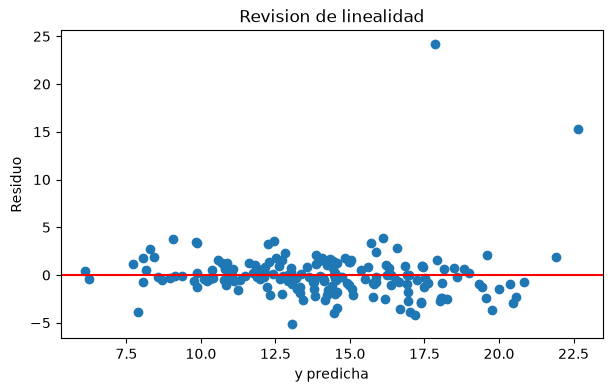

In [9]:
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuos)
plt.axhline(0, color="red")
plt.xlabel("y predicha")
plt.ylabel("Residuo")
plt.title("Revision de linealidad")
plt.show()

La mayoría de los residuos está alrededor de cero y no forma una curva clara, no veo una señal fuerte de no linealidad, aunque hay dos puntos con residuos positivos mucho mayores que los demás.

### 2. Correlación en los errores

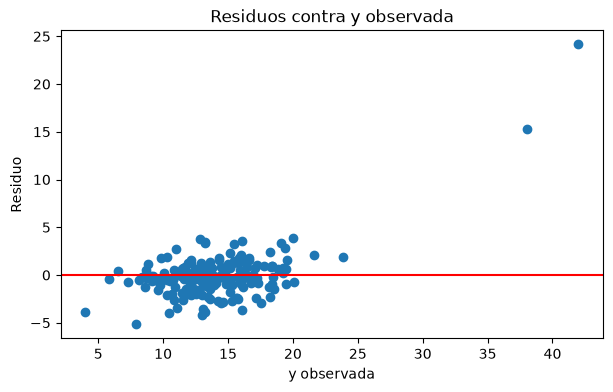

In [10]:
plt.figure(figsize=(7, 4))
plt.scatter(y, residuos)
plt.axhline(0, color="red")
plt.xlabel("y observada")
plt.ylabel("Residuo")
plt.title("Residuos contra y observada")
plt.show()

Los valores más altos de y tienen residuos positivos grandes, esto indica que el modelo los subestimó, pero esta gráfica no permite confirmar que los errores estén correlacionados entre observaciones.

### 3. Heteroscedasticidad (varianza no constante)

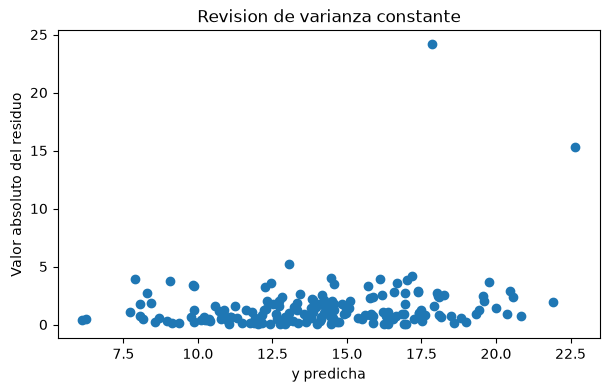

In [11]:
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, np.abs(residuos))
plt.xlabel("y predicha")
plt.ylabel("Valor absoluto del residuo")
plt.title("Revision de varianza constante")
plt.show()

No se observa un embudo claro en la mayoría de los puntos, los cambios más grandes aparecen por dos residuos extremos, con esta gráfica no afirmaría que hay heteroscedasticidad solo por esos dos casos.

### 4. Valores atípicos

,Observacion,y observada,y predicha,Residuo / sigma
0,181,42.0,17.857094,8.876817
1,183,38.0,22.665755,5.638065


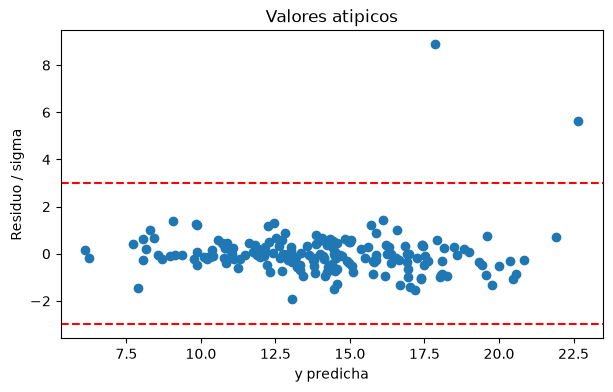

In [12]:
n = len(y)
p = X.shape[1]

sigma = np.sqrt(np.sum(residuos ** 2) / (n - p - 1))
r = residuos / sigma
atipicos = np.where(np.abs(r) >= 3)[0]

display(pd.DataFrame({
    "Observacion": atipicos + 1,
    "y observada": y.iloc[atipicos].values,
    "y predicha": y_pred[atipicos],
    "Residuo / sigma": r.iloc[atipicos].values
}))

plt.figure(figsize=(7, 4))
plt.scatter(y_pred, r)
plt.axhline(3, color="red", linestyle="--")
plt.axhline(-3, color="red", linestyle="--")
plt.xlabel("y predicha")
plt.ylabel("Residuo / sigma")
plt.title("Valores atipicos")
plt.show()

Las observaciones 181 y 183 superan el límite de tres en valor absoluto, sus respuestas quedaron bastante por encima de las predicciones, las marco para revisión pero no las elimino porque no tengo evidencia de que sean datos incorrectos.

### 5. Puntos palanca

Limite: 0.03278688524590164
Posibles puntos palanca: 72


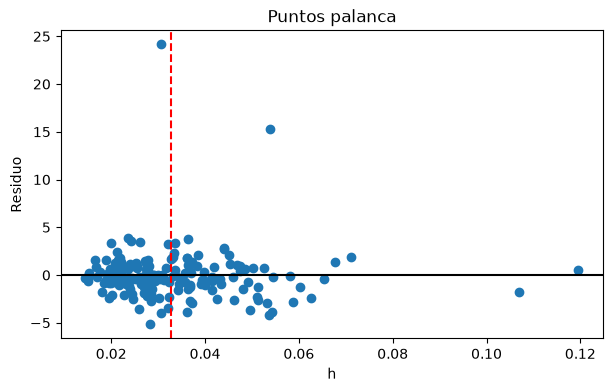

In [13]:
# Agregar el intercepto para calcular h
A = np.hstack([np.ones((n, 1)), X.values])
B = np.linalg.inv(A.T @ A)
C = A @ B
h = np.sum(C * A, axis=1)

lim = (p + 1) / n
palanca = np.where(h >= lim)[0]

print("Limite:", lim)
print("Posibles puntos palanca:", len(palanca))

plt.figure(figsize=(7, 4))
plt.scatter(h, residuos)
plt.axvline(lim, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.xlabel("h")
plt.ylabel("Residuo")
plt.title("Puntos palanca")
plt.show()

Aparecen 72 posibles puntos palanca que están a la derecha de la línea roja, este límite corresponde a la palanca promedio y por eso señala muchos casos, no significa que todos deban eliminarse, la observación 183 también tiene un residuo grande, mientras que la 181 tiene un residuo grande pero queda por debajo del límite de palanca.

### 6. Colinealidad

,Factor,VIF
0,x1,4.532588
1,x2,4.533906
2,x3,1.004724
3,grupo_B,1.221303
4,grupo_C,1.201796


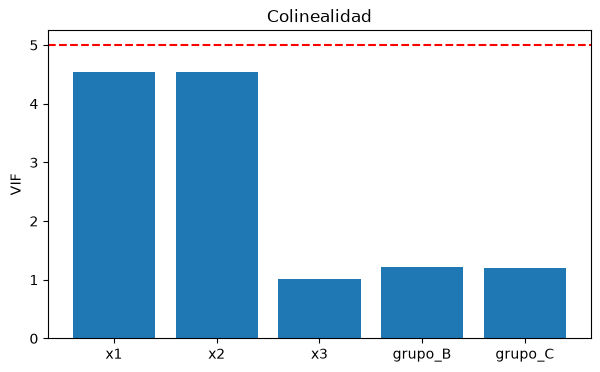

In [14]:
# Calcular VIF con regresiones auxiliares
vif = []

for col in X.columns:
    aux = LinearRegression()
    aux.fit(X.drop(columns=[col]), X[col])
    r2 = aux.score(X.drop(columns=[col]), X[col])
    vif.append(1 / (1 - r2))

vif = pd.DataFrame({
    "Factor": X.columns,
    "VIF": vif
})

display(vif)

plt.figure(figsize=(7, 4))
plt.bar(vif["Factor"], vif["VIF"])
plt.axhline(5, color="red", linestyle="--")
plt.ylabel("VIF")
plt.title("Colinealidad")
plt.show()

x1 y x2 tienen los VIF más altos, aproximadamente 4.53, son los factores que más comparten información con los demás, ninguno supera el criterio de cinco, aunque eso no significa que sean independientes, por esta relación pruebo Ridge como alternativa.

## PREGUNTAS

**¿Cuál fue el error?**

No alcancé a realizar los diagnósticos, esta parte quedó pendiente.

**¿Cuál es la corrección?**

Debía calcular las predicciones y los residuos, después revisar cada uno de los seis problemas e interpretar los resultados.

**¿Por qué se cometió el error?**

Me atoré en la limpieza y no conseguí ajustar el modelo, además ya no tuve tiempo para continuar con los diagnósticos.

**¿Cómo puedo evitar este error en el futuro?**

Puedo preparar una plantilla con el cálculo de residuos y los seis diagnósticos, cuando el modelo funcione adapto las variables y reviso cada resultado antes de interpretarlo.

## Comparación de modelos con validación cruzada

In [15]:
X_cv = df_cv.drop(columns=["y"])
y_cv = df_cv["y"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for nombre in ["Lineal", "Ridge"]:
    mse = []

    for train, test in kf.split(X_cv):
        X_train = X_cv.iloc[train].copy()
        X_test = X_cv.iloc[test].copy()
        y_train = y_cv.iloc[train]
        y_test = y_cv.iloc[test]

        # Aprender el relleno solamente con entrenamiento
        for col in ["x2", "x3"]:
            mediana = X_train[col].median()
            X_train[col] = X_train[col].fillna(mediana)
            X_test[col] = X_test[col].fillna(mediana)

        moda = X_train["grupo"].mode()[0]
        X_train["grupo"] = X_train["grupo"].fillna(moda)
        X_test["grupo"] = X_test["grupo"].fillna(moda)

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), ["x1", "x2", "x3"]),
                ("cat", OneHotEncoder(drop="first", sparse_output=False),
                 ["grupo"])
            ],
            remainder="drop"
        )

        if nombre == "Lineal":
            mod = LinearRegression()
        else:
            mod = Ridge(alpha=1)

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", mod)
            ]
        )

        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_test)
        mse.append(mean_squared_error(y_test, pred))

    resultados.append([nombre, np.mean(mse), np.std(mse)])

resultados = pd.DataFrame(
    resultados,
    columns=["Modelo", "MSE promedio", "Desviacion del MSE"]
)

display(resultados)

,Modelo,MSE promedio,Desviacion del MSE
0,Lineal,7.763128,6.820880
1,Ridge,7.757160,6.839823


Probé ambos modelos con las mismas cinco particiones para compararlos en las mismas condiciones, fijé la semilla para poder repetir la división, dentro de cada vuelta calculé el relleno y ajusté el preprocesamiento usando solo entrenamiento.

El modelo lineal obtuvo un MSE promedio de aproximadamente 7.763 y Ridge de 7.757, la diferencia es muy pequeña, la desviación del MSE fue aproximadamente 6.821 para el lineal y 6.840 para Ridge, así que Ridge no resultó más estable en esta comparación.

## PREGUNTAS

**¿Cuál fue el error?**

No alcancé a comparar los modelos ni a realizar la validación cruzada.

**¿Cuál es la corrección?**

Debía evaluar el modelo lineal y Ridge con las mismas particiones, comparar su error promedio y revisar cuánto cambiaba entre particiones.

**¿Por qué se cometió el error?**

La limpieza me impidió avanzar y el tiempo no me alcanzó para llegar a esta parte.

**¿Cómo puedo evitar este error en el futuro?**

Puedo dejar preparado el ciclo de validación, usar las mismas particiones para ambos modelos y comprobar que el relleno y el escalamiento se aprendan solo con los datos de entrenamiento.

## Conclusión

Corregí los formatos, unifiqué las categorías y rellené los faltantes sin eliminar observaciones, el modelo explica aproximadamente el 59.5% de la variación de y en entrenamiento, pero aparecen dos casos que predice bastante por debajo de su valor real.

La validación muestra resultados muy parecidos entre el modelo lineal y Ridge, mantendría el lineal porque la penalización no dio una mejora clara con el alpha probado, también dejaría señaladas las dos observaciones atípicas para revisar su origen, sin borrarlas solo para bajar el error.

## PREGUNTAS

**¿Cuál fue el error?**

No alcancé a escribir una conclusión de la parte práctica.

**¿Cuál es la corrección?**

Debía reunir los resultados del modelo, los diagnósticos y la validación para explicar qué modelo conservaría y qué problemas seguían pendientes.

**¿Por qué se cometió el error?**

No tenía los resultados necesarios para concluir porque no pude terminar los procedimientos anteriores y se acabó el tiempo.

**¿Cómo puedo evitar este error en el futuro?**

Puedo anotar un hallazgo breve después de cada apartado, al final reúno esas notas y escribo una conclusión basada en los resultados que sí obtuve.